In [19]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as stats
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import ast

import scipy.sparse

In [ ]:
adata = sc.read_h5ad('/NicheCompass/artifacts/single_sample/26032025_173236/model/xenium_adult_colon_hs_NicheCompass_AM_26032025_173236_raw.h5ad')

In [ ]:
gps_df = pd.read_csv('/NicheCompass/artifacts/single_sample/26032025_173236/figures/log_bayes_factor_2.3_niche2_enriched_gps_summary.csv')

# GP 18

In [45]:
filtered_df = gps_df[gps_df['gp_name']== 'Add-on_18_GP']
genes_string = filtered_df['gp_source_genes'].values[0]
source_genes = ast.literal_eval(genes_string)
genes_string = filtered_df['gp_target_genes'].values[0]
target_genes = ast.literal_eval(genes_string)

In [46]:
gp18_genes = list(set(source_genes + target_genes))

In [47]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log)
sc.pp.log1p(adata_log)

In [48]:
cell_types_of_interest = ['Fibroblasts', 'Macrophages', 'CD4 T', 'Mast cells', 'Glial cells', 'Stem cells', 'TA']

## Calculate Gene-Gene Correlation Matrices for Each Niche-Cell Type Combination

In [49]:
def calculate_correlation_matrix(adata, genes, niche, cell_type):
    """Calculate correlation matrix for a specific niche and cell type."""
    # Filter the data
    mask = (adata.obs['latent_leiden_0.4'] == str(niche)) & (adata.obs['C_scANVI'] == cell_type)
    
    # Check if we have any cells matching the criteria
    if sum(mask) < 10:
        return None, sum(mask)
    
    subset = adata[mask, genes].copy()
    
    # Check if all genes are available
    available_genes = [gene for gene in genes if gene in subset.var_names]
    if len(available_genes) < 2:  # Need at least 2 genes for correlation
        return None, subset.n_obs
    
    # Extract the gene expression matrix
    if scipy.sparse.issparse(subset.X):
        expr_matrix = subset.X.toarray()
    else:
        expr_matrix = subset.X
    
    # Handle potential infinite or NaN values
    expr_matrix = np.nan_to_num(expr_matrix)
    
    # Transpose to get genes as columns (cells x genes)
    expr_df = pd.DataFrame(expr_matrix, columns=available_genes)
    
    # Calculate correlation matrix using pandas (handles edge cases better)
    # Use 'spearman' for rank correlation (more robust)
    correlation_matrix = expr_df.corr(method='spearman')
    
    return correlation_matrix, subset.n_obs

## Calculate Differential Correlation

In [50]:
def calculate_differential_correlation(corr_niche2, corr_niche8):
    """Calculate differential correlation between two niches."""
    # Simple difference between correlation matrices
    diff_corr = corr_niche2 - corr_niche8
    
    # Calculate magnitude of change
    magnitude = np.abs(diff_corr)
    
    return diff_corr, magnitude

## Identify Significant Changes in Network Topology

In [51]:
def find_significant_changes(diff_corr, threshold=0.4):
    """Find gene pairs with significant changes in correlation."""
    # Get the upper triangle of the matrix (excluding diagonal)
    triu_indices = np.triu_indices_from(diff_corr.values, k=1)
    
    # Extract the values from the upper triangle
    diff_values = diff_corr.values[triu_indices]
    
    # Get the pairs of genes
    pairs = [(diff_corr.index[i], diff_corr.columns[j]) for i, j in zip(*triu_indices)]
    
    # Create a dataframe with the pairs and differences
    result = pd.DataFrame({
        'gene1': [p[0] for p in pairs],
        'gene2': [p[1] for p in pairs],
        'diff_correlation': diff_values,
        'abs_diff': np.abs(diff_values)
    })
    
    # Filter for significant changes
    significant = result[result['abs_diff'] > threshold].sort_values('abs_diff', ascending=False)
    
    return significant

## Execute Analysis for All Cell Types of Interest

In [52]:
# Dictionary to store results
results = {}

# Run analysis for each cell type
for cell_type in cell_types_of_interest:
    print(f"Processing {cell_type}...")
    
    # Calculate correlation matrices
    corr_niche2, n_cells_niche2 = calculate_correlation_matrix(adata_log, gp18_genes, "2", cell_type)
    corr_niche8, n_cells_niche8 = calculate_correlation_matrix(adata_log, gp18_genes, "8", cell_type)
    
    # Skip if not enough cells in either niche
    if corr_niche2 is None or corr_niche8 is None:
        print(f"  Skipping {cell_type}: insufficient cells (Niche 2: {n_cells_niche2}, Niche 8: {n_cells_niche8})")
        continue
    
    # Calculate differential correlation
    diff_corr, magnitude = calculate_differential_correlation(corr_niche2, corr_niche8)
    
    # Find significant changes
    significant_changes = find_significant_changes(diff_corr)
    
    # Store results
    results[cell_type] = {
        'corr_niche2': corr_niche2,
        'corr_niche8': corr_niche8,
        'diff_corr': diff_corr,
        'magnitude': magnitude,
        'significant_changes': significant_changes,
        'n_cells_niche2': n_cells_niche2,
        'n_cells_niche8': n_cells_niche8
    }
    
    print(f"  Found {len(significant_changes)} significant changes in gene-gene correlations")

Processing Fibroblasts...
  Found 38 significant changes in gene-gene correlations
Processing Macrophages...
  Found 280 significant changes in gene-gene correlations
Processing CD4 T...
  Found 379 significant changes in gene-gene correlations
Processing Mast cells...
  Found 1336 significant changes in gene-gene correlations
Processing Glial cells...
  Found 166 significant changes in gene-gene correlations
Processing Stem cells...
  Found 13 significant changes in gene-gene correlations
Processing TA...
  Found 12 significant changes in gene-gene correlations


## Visualize the Results

In [ ]:
def visualize_differential_network(cell_type, results, top_n=10):
    """Visualize differential correlation network for a cell type."""
    if cell_type not in results:
        print(f"No results available for {cell_type}")
        return
    
    # Get top N most changed gene pairs
    significant = results[cell_type]['significant_changes']
    if len(significant) == 0:
        print(f"No significant changes for {cell_type}")
        return
    
    top_changes = significant.head(top_n)
    
    # Create a graph
    G = nx.Graph()
    
    # Add nodes (genes)
    unique_genes = set(top_changes['gene1'].tolist() + top_changes['gene2'].tolist())
    for gene in unique_genes:
        G.add_node(gene)
    
    # Add edges with differential correlation as weight
    for _, row in top_changes.iterrows():
        G.add_edge(row['gene1'], row['gene2'], 
                  weight=row['diff_correlation'],
                  abs_weight=row['abs_diff'])
    
    # Set up plot with specific axes for the colorbar
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Define node positions using spring layout
    pos = nx.spring_layout(G, seed=42, k=0.8)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue', alpha=0.8, ax=ax)
    
    # Draw edges with color based on correlation change
    edges = G.edges()
    edge_colors = [G[u][v]['weight'] for u, v in edges]
    
    # Color edges based on direction of change
    edge_cmap = plt.cm.RdBu_r
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=3, 
                          edge_color=edge_colors, edge_cmap=edge_cmap,
                          edge_vmin=-1, edge_vmax=1, alpha=0.7, ax=ax)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Add a colorbar - explicitly specify the axes
    sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=plt.Normalize(vmin=-1, vmax=1))
    sm.set_array([])
    
    # Create a colorbar and pass the axis where it should be drawn
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Differential Correlation (Niche 2 - Niche 8)')
    
    ax.set_title(f'Top {top_n} Differential Gene-Gene Correlations in {cell_type}\n' +
                f'Niche 2: {results[cell_type]["n_cells_niche2"]} cells, ' +
                f'Niche 8: {results[cell_type]["n_cells_niche8"]} cells')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/NicheCompass/artifacts/single_sample/26032025_173236/figures/add_on_18/differential_network_{cell_type.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

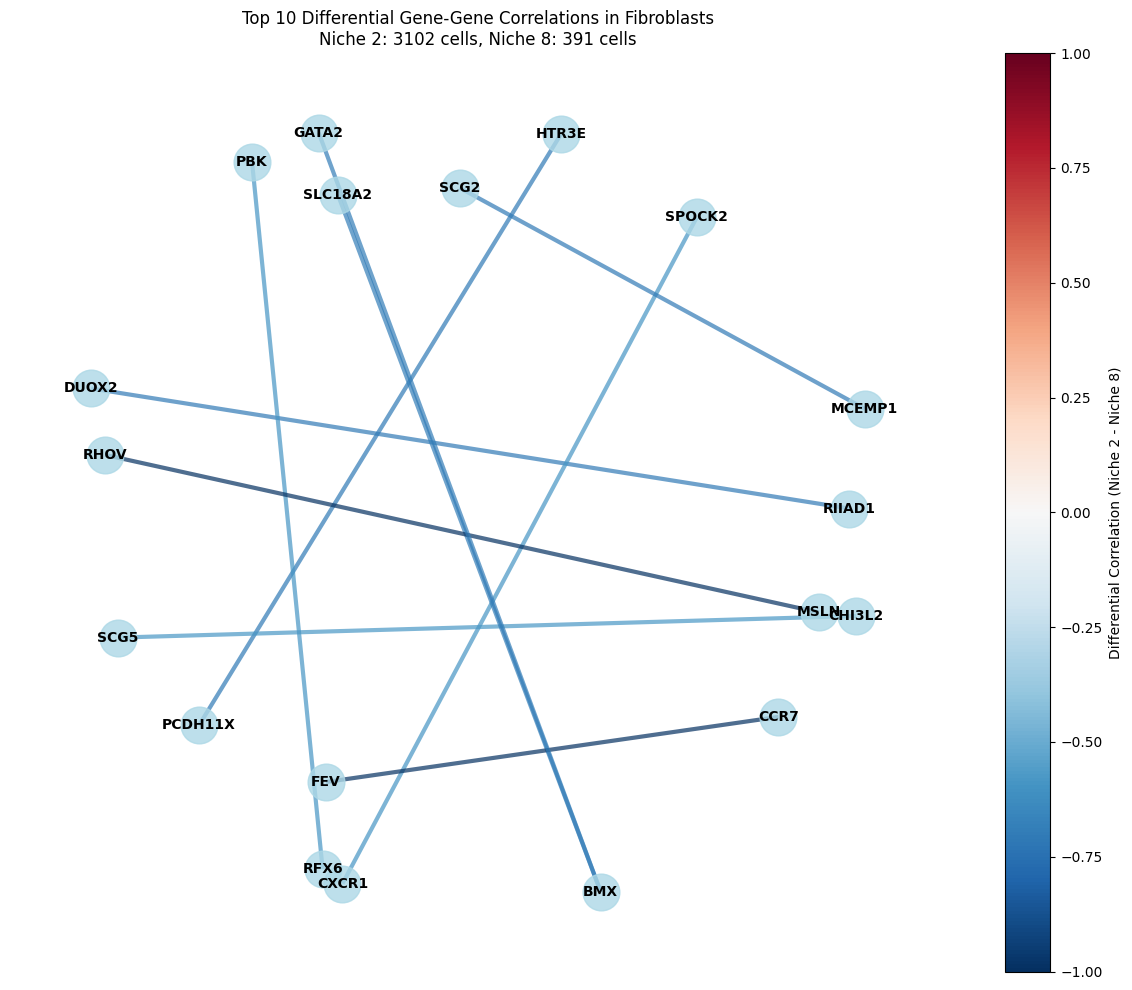

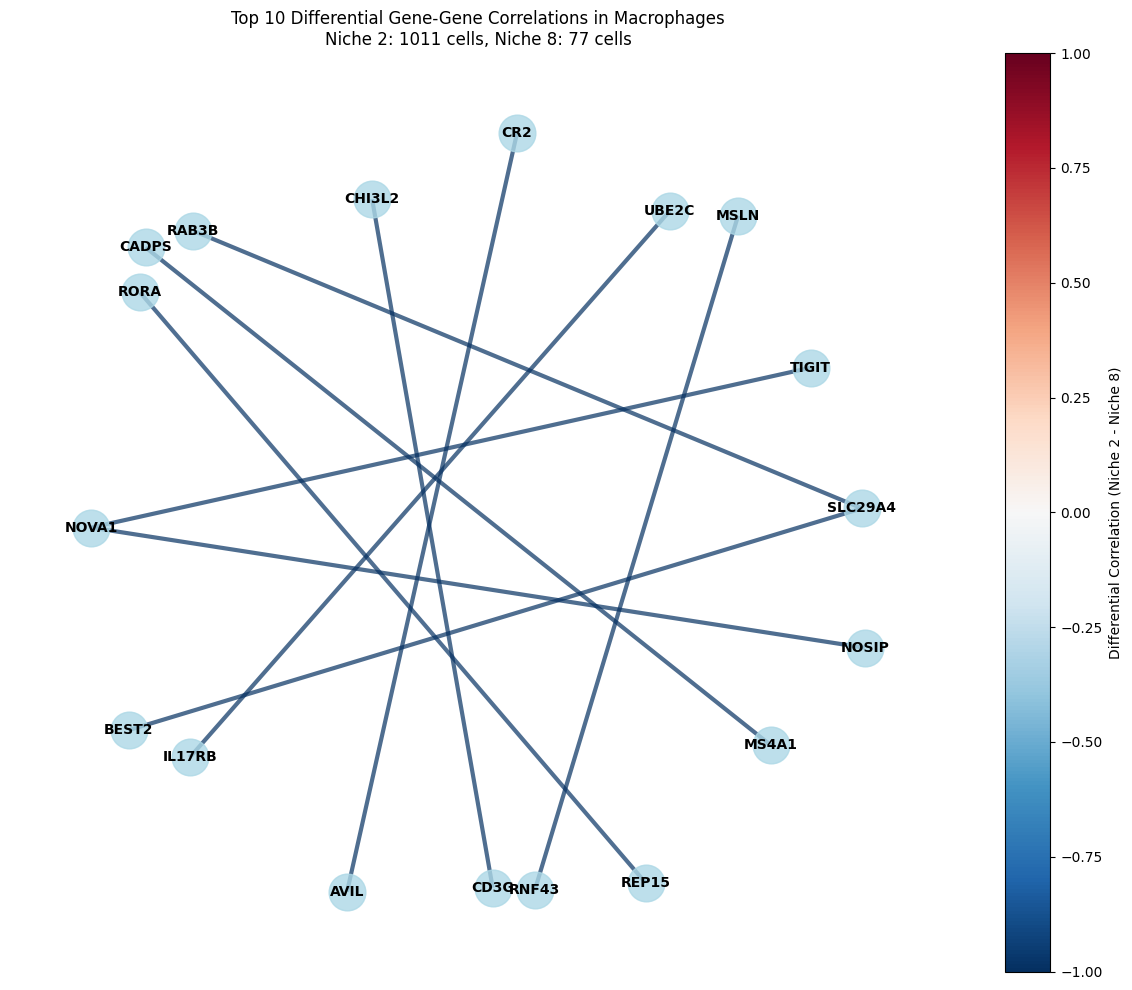

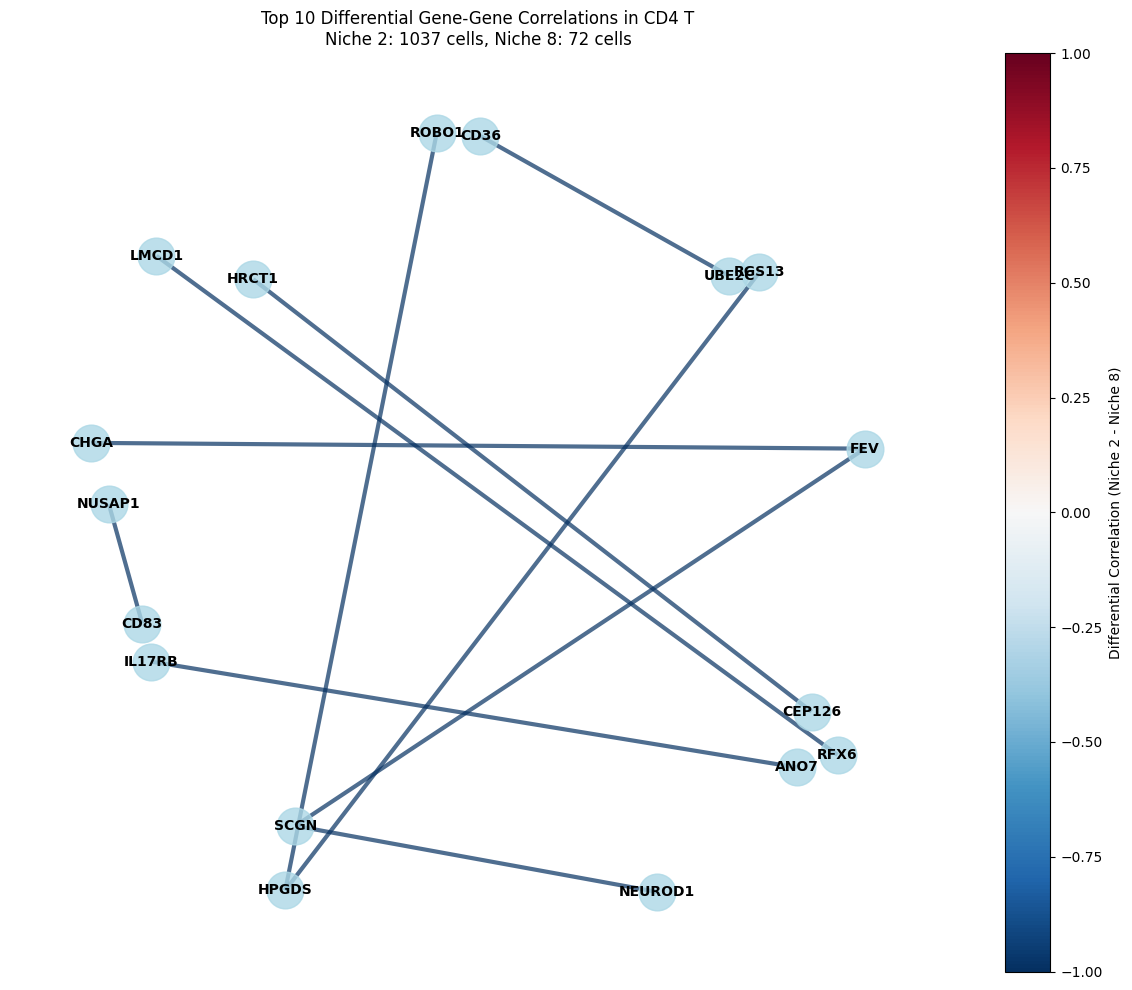

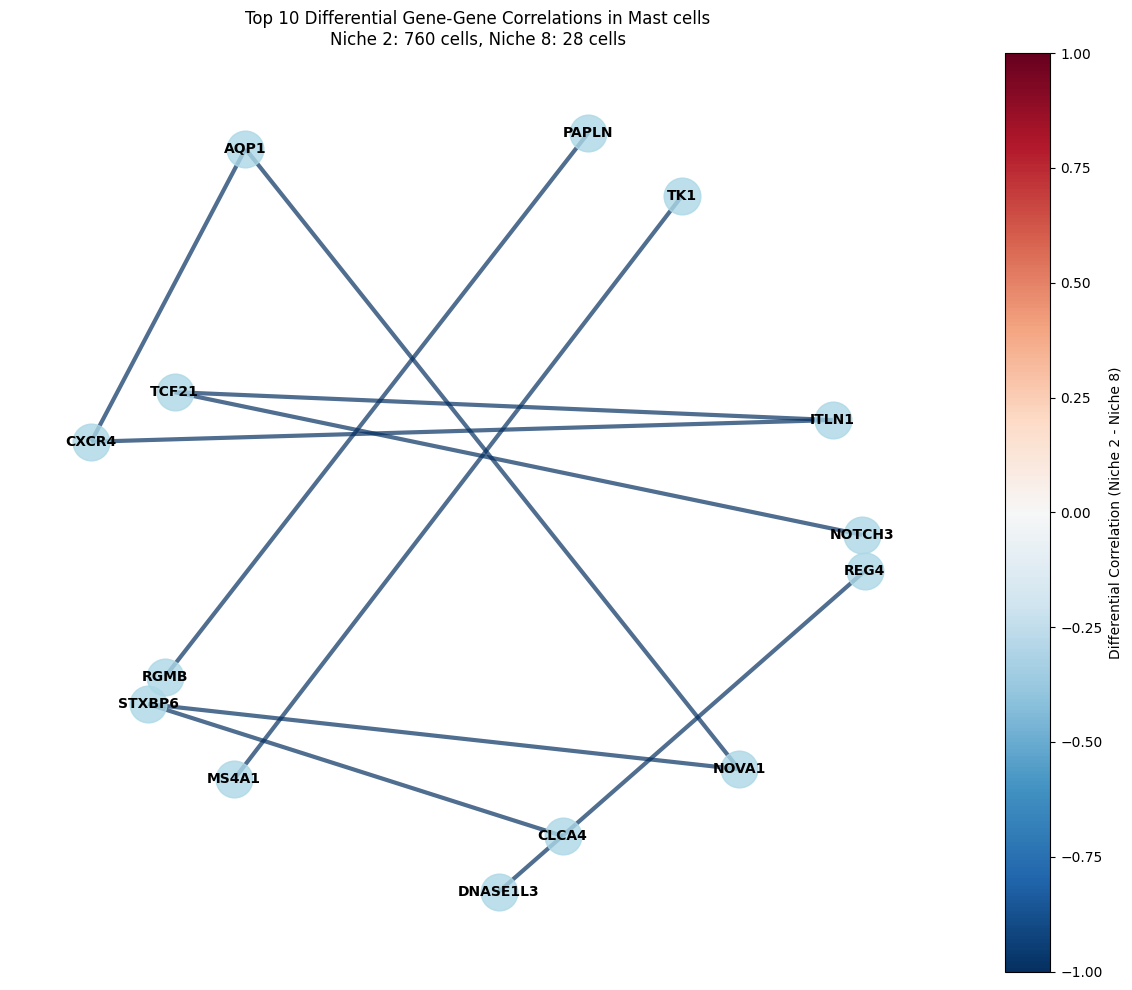

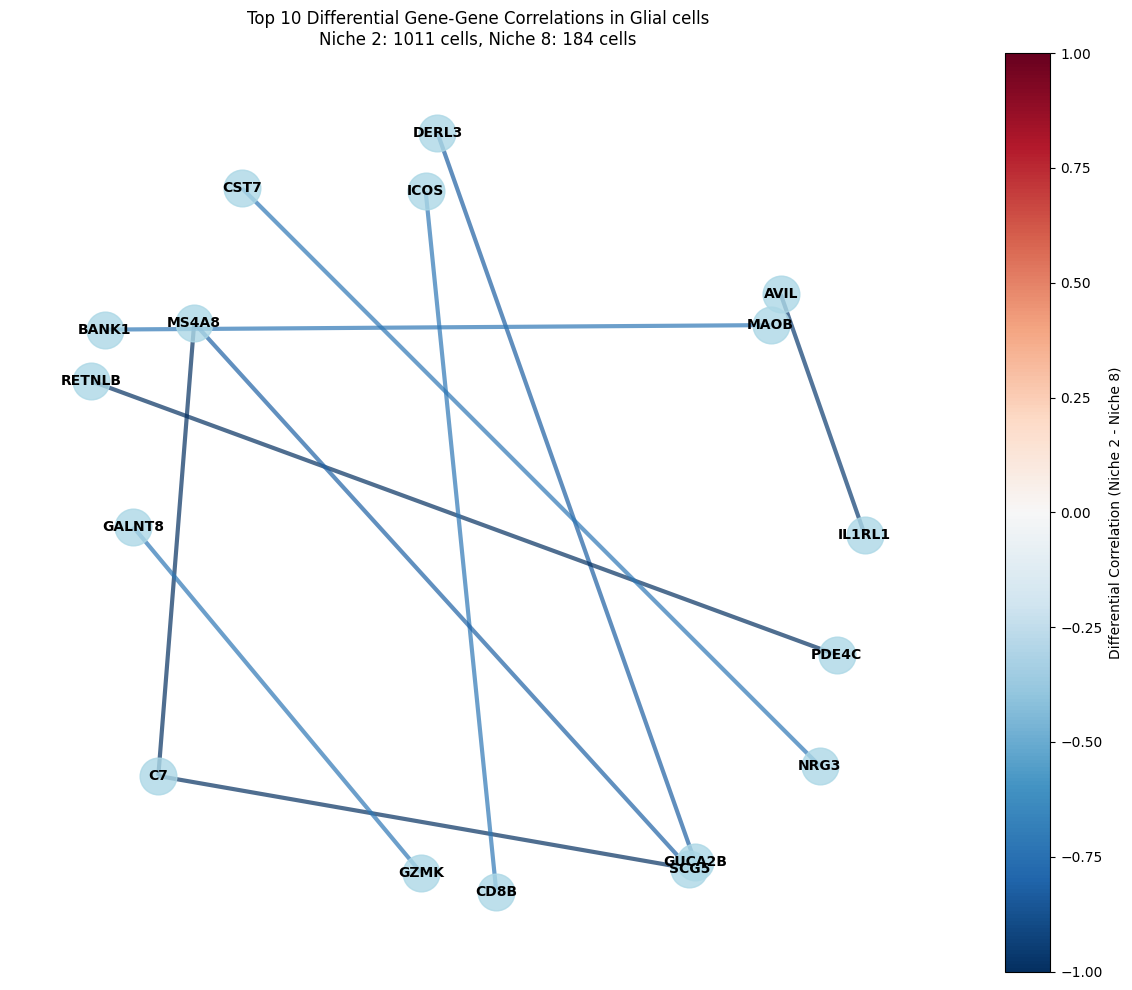

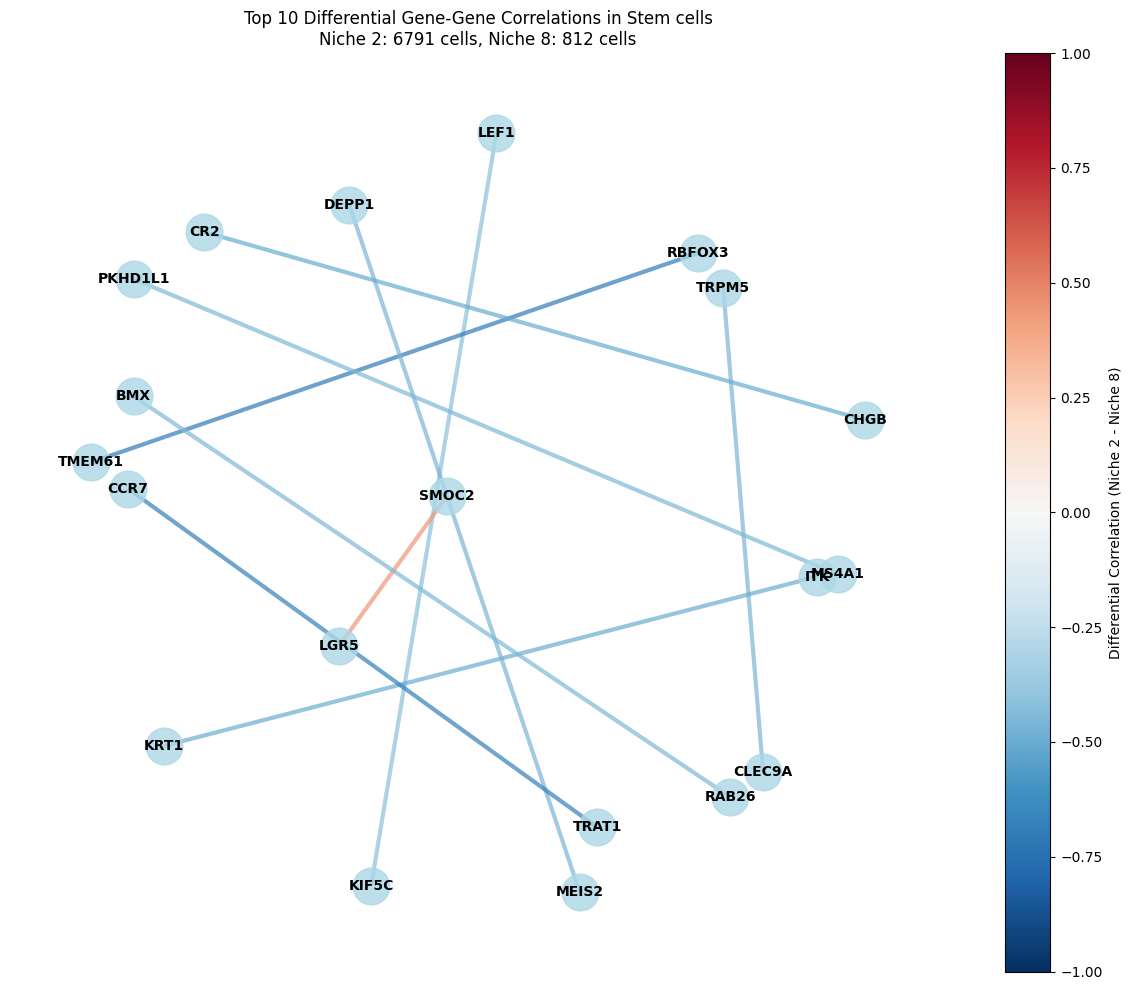

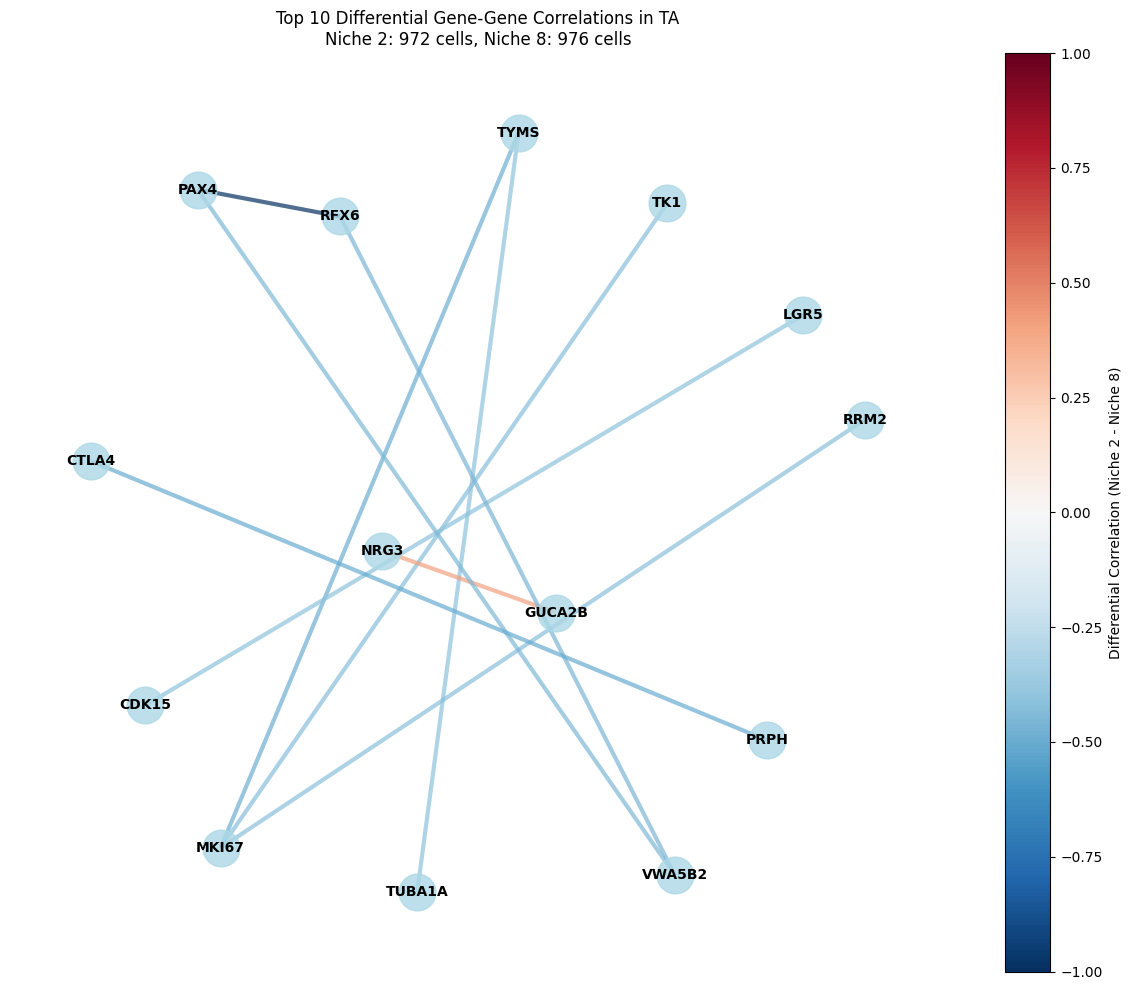

In [54]:
# Generate network visualizations for all cell types
for cell_type in results.keys():
    visualize_differential_network(cell_type, results)

## Summarize the Most Consistent Network Changes Across Cell Types

In [55]:
def summarize_network_changes(results):
    """Summarize the most consistent network changes across cell types."""
    # Collect all significant changes
    all_changes = []
    
    for cell_type, result in results.items():
        sig_changes = result['significant_changes']
        
        if len(sig_changes) > 0:
            # Add cell type information
            sig_changes = sig_changes.copy()
            sig_changes['cell_type'] = cell_type
            
            all_changes.append(sig_changes)
    
    if not all_changes:
        print("No significant changes found in any cell type")
        return None
    
    # Combine all changes
    all_changes_df = pd.concat(all_changes, ignore_index=True)
    
    # Create a unique identifier for each gene pair
    all_changes_df['gene_pair'] = all_changes_df.apply(
        lambda x: tuple(sorted([x['gene1'], x['gene2']])), axis=1)
    
    # Count occurrences of each gene pair
    pair_counts = all_changes_df.groupby('gene_pair').size().reset_index(name='frequency')
    
    # Calculate average magnitude of change for each gene pair
    pair_magnitude = all_changes_df.groupby('gene_pair')['abs_diff'].mean().reset_index(name='avg_magnitude')
    
    # Merge counts and magnitudes
    pair_summary = pd.merge(pair_counts, pair_magnitude, on='gene_pair')
    
    # Sort by frequency and then magnitude
    pair_summary = pair_summary.sort_values(['frequency', 'avg_magnitude'], ascending=False)
    
    # Extract gene1 and gene2 from gene_pair
    pair_summary['gene1'] = pair_summary['gene_pair'].apply(lambda x: x[0])
    pair_summary['gene2'] = pair_summary['gene_pair'].apply(lambda x: x[1])
    
    # Drop gene_pair column
    pair_summary = pair_summary.drop('gene_pair', axis=1)
    
    # Reorder columns
    pair_summary = pair_summary[['gene1', 'gene2', 'frequency', 'avg_magnitude']]
    
    return pair_summary

In [56]:
network_summary = summarize_network_changes(results)

Summary of most consistent network changes across cell types:
        gene1   gene2  frequency  avg_magnitude
1233      FEV    SCGN          2       0.967916
2065    REP15  RETNLB          2       0.814518
2082    RGS13   ROBO1          2       0.761899
544      CCR7     FEV          2       0.758722
330     BEST2    NKG7          2       0.726918
626       CD5  CHI3L2          2       0.718245
1626    ITLN1   NOVA1          2       0.710533
1729    LMCD1  PLXND1          2       0.624083
71    AFAP1L2     TK1          2       0.596523
1275     FRZB    SOX6          2       0.590959
1834   MS4A12  TMIGD1          2       0.583844
814      CHGA    NKG7          2       0.574791
1349      GCG   INSM1          2       0.572264
2101    RNF43    SPIB          2       0.559245
399      C1QC   MS4A1          2       0.547335


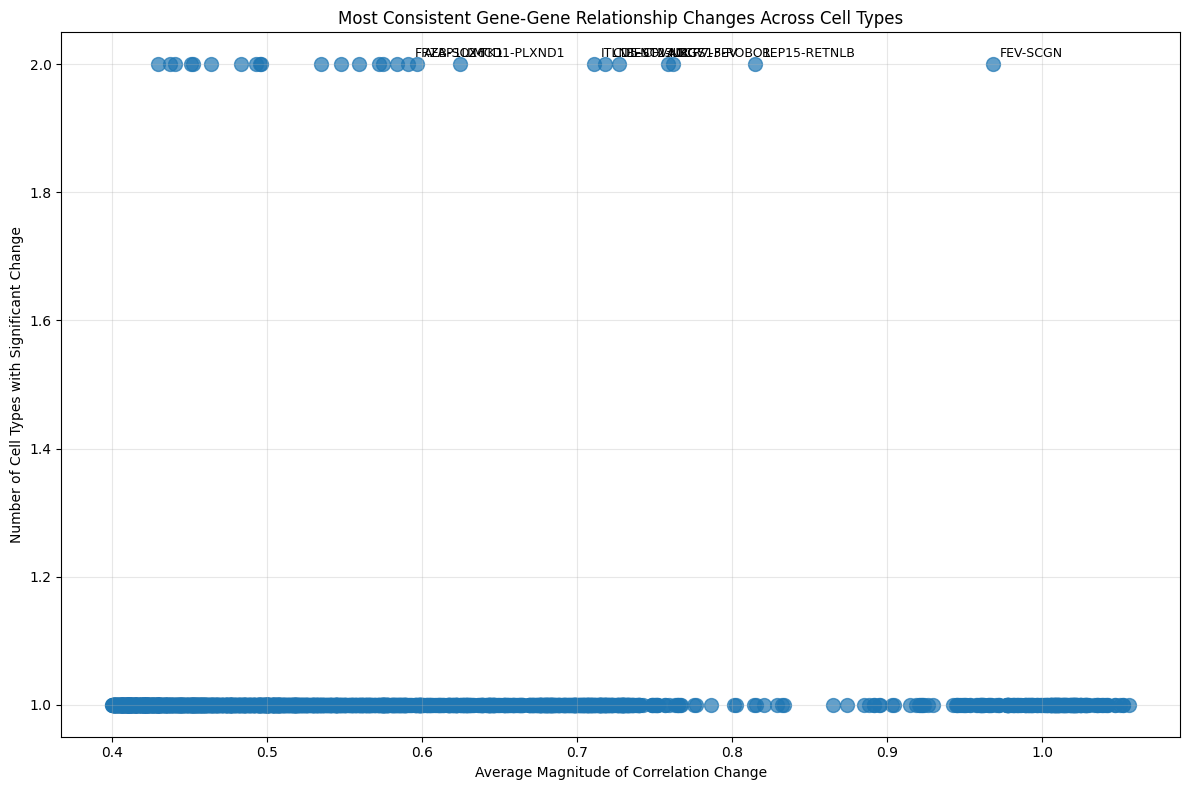

In [ ]:
if network_summary is not None:
    print("Summary of most consistent network changes across cell types:")
    print(network_summary.head(15))
    
    # Visualize top gene pairs
    plt.figure(figsize=(12, 8))
    
    # Plot frequency vs magnitude
    plt.scatter(network_summary['avg_magnitude'], network_summary['frequency'], 
               alpha=0.7, s=100)
    
    # Label top pairs
    for _, row in network_summary.head(10).iterrows():
        plt.annotate(f"{row['gene1']}-{row['gene2']}", 
                    (row['avg_magnitude'], row['frequency']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9)
    
    plt.xlabel('Average Magnitude of Correlation Change')
    plt.ylabel('Number of Cell Types with Significant Change')
    plt.title('Most Consistent Gene-Gene Relationship Changes Across Cell Types')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/NicheCompass/artifacts/single_sample/26032025_173236/figures/add_on_18/consistent_network_changes.png', dpi=300, bbox_inches='tight')
    plt.show()

# GP 26

In [22]:
filtered_df = gps_df[gps_df['gp_name']== 'Add-on_26_GP']
genes_string = filtered_df['gp_source_genes'].values[0]
source_genes = ast.literal_eval(genes_string)
genes_string = filtered_df['gp_target_genes'].values[0]
target_genes = ast.literal_eval(genes_string)

In [23]:
gp26_genes = list(set(source_genes + target_genes))

In [25]:
adata_filtered = adata_log[adata_log.obs['latent_leiden_0.4'].isin(['1','2', '10', '11'])]

In [27]:
adata_filtered.obs['niche'] = adata_filtered.obs['latent_leiden_0.4'].copy()
adata_filtered.obs['latent_leiden_0.4'] = adata_filtered.obs['latent_leiden_0.4'].astype('category') 
adata_filtered.obs['latent_leiden_0.4'] = adata_filtered.obs['latent_leiden_0.4'].cat.add_categories(['Stem cell niche', 'Colonocyte niche'])
adata_filtered.obs.loc[(adata_filtered.obs['latent_leiden_0.4'] == '1'), 'latent_leiden_0.4'] = 'Stem cell niche'
adata_filtered.obs.loc[(adata_filtered.obs['latent_leiden_0.4'] == '2'), 'latent_leiden_0.4'] = 'Stem cell niche'
adata_filtered.obs.loc[(adata_filtered.obs['latent_leiden_0.4'] == '10'), 'latent_leiden_0.4'] = 'Colonocyte niche'
adata_filtered.obs.loc[(adata_filtered.obs['latent_leiden_0.4'] == '11'), 'latent_leiden_0.4'] = 'Colonocyte niche'

In [37]:
adata_filtered.obs['C_scANVI'].value_counts()

C_scANVI
Colonocyte              22122
Stem cells              13853
Goblet cells             8627
Fibroblasts              6019
TA                       4853
Tuft cells               4415
EECs                     3027
BEST4+ epithelial        2445
Glial cells              2290
Plasma cells             1815
Macrophages              1787
Endothelial cells        1475
CD4 T                    1373
Mast cells               1265
Myofibroblasts            950
B cells                   531
CD8 T                     520
Mature venous EC          403
Arterial capillary        271
Pericytes                 185
DC                        148
NK                        109
Immune Cycling cells       78
Mature arterial EC         71
LEC                        21
Monocytes                  16
ILCs                        3
Name: count, dtype: int64

## Execute Analysis for All Cell Types of Interest

In [39]:
# Dictionary to store results
results = {}

# Run analysis for each cell type
for cell_type in cell_types_of_interest:
    print(f"Processing {cell_type}...")
    
    # Calculate correlation matrices
    corr_niche2, n_cells_niche2 = calculate_correlation_matrix(adata_filtered, gp26_genes, "Stem cell niche", cell_type)
    corr_niche8, n_cells_niche8 = calculate_correlation_matrix(adata_filtered, gp26_genes, "Colonocyte niche", cell_type)
    
    # Skip if not enough cells in either niche
    if corr_niche2 is None or corr_niche8 is None:
        print(f"  Skipping {cell_type}: insufficient cells (Stem cell niche: {n_cells_niche2}, Colonocyte niche: {n_cells_niche8})")
        continue
    
    # Calculate differential correlation
    diff_corr, magnitude = calculate_differential_correlation(corr_niche2, corr_niche8)
    
    # Find significant changes
    significant_changes = find_significant_changes(diff_corr)
    
    # Store results
    results[cell_type] = {
        'corr_niche2': corr_niche2,
        'corr_niche8': corr_niche8,
        'diff_corr': diff_corr,
        'magnitude': magnitude,
        'significant_changes': significant_changes,
        'n_cells_niche2': n_cells_niche2,
        'n_cells_niche8': n_cells_niche8
    }
    
    print(f"  Found {len(significant_changes)} significant changes in gene-gene correlations")

Processing Fibroblasts...
  Found 261 significant changes in gene-gene correlations
Processing Macrophages...
  Found 461 significant changes in gene-gene correlations
Processing CD4 T...
  Found 1243 significant changes in gene-gene correlations
Processing Mast cells...
  Found 1594 significant changes in gene-gene correlations
Processing Glial cells...
  Skipping Glial cells: insufficient cells (Stem cell niche: 2281, Colonocyte niche: 9)
Processing Stem cells...
  Skipping Stem cells: insufficient cells (Stem cell niche: 13852, Colonocyte niche: 1)
Processing TA...
  Found 173 significant changes in gene-gene correlations


## Visualize the Results

In [ ]:
def visualize_differential_network(cell_type, results, top_n=10):
    """Visualize differential correlation network for a cell type."""
    if cell_type not in results:
        print(f"No results available for {cell_type}")
        return
    
    # Get top N most changed gene pairs
    significant = results[cell_type]['significant_changes']
    if len(significant) == 0:
        print(f"No significant changes for {cell_type}")
        return
    
    top_changes = significant.head(top_n)
    
    # Create a graph
    G = nx.Graph()
    
    # Add nodes (genes)
    unique_genes = set(top_changes['gene1'].tolist() + top_changes['gene2'].tolist())
    for gene in unique_genes:
        G.add_node(gene)
    
    # Add edges with differential correlation as weight
    for _, row in top_changes.iterrows():
        G.add_edge(row['gene1'], row['gene2'], 
                  weight=row['diff_correlation'],
                  abs_weight=row['abs_diff'])
    
    # Set up plot with specific axes for the colorbar
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Define node positions using spring layout
    pos = nx.spring_layout(G, seed=42, k=0.8)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue', alpha=0.8, ax=ax)
    
    # Draw edges with color based on correlation change
    edges = G.edges()
    edge_colors = [G[u][v]['weight'] for u, v in edges]
    
    # Color edges based on direction of change
    edge_cmap = plt.cm.RdBu_r
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=3, 
                          edge_color=edge_colors, edge_cmap=edge_cmap,
                          edge_vmin=-1, edge_vmax=1, alpha=0.7, ax=ax)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Add a colorbar - explicitly specify the axes
    sm = plt.cm.ScalarMappable(cmap=edge_cmap, norm=plt.Normalize(vmin=-1, vmax=1))
    sm.set_array([])
    
    # Create a colorbar and pass the axis where it should be drawn
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Differential Correlation (Stem cell niches - Colonocyte niches)')
    
    ax.set_title(f'Top {top_n} Differential Gene-Gene Correlations in {cell_type}\n' +
                f'Stem cell niches: {results[cell_type]["n_cells_niche2"]} cells, ' +
                f'Colonocyte niches: {results[cell_type]["n_cells_niche8"]} cells')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/NicheCompass/artifacts/single_sample/26032025_173236/figures/add_on_26/differential_network_{cell_type.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

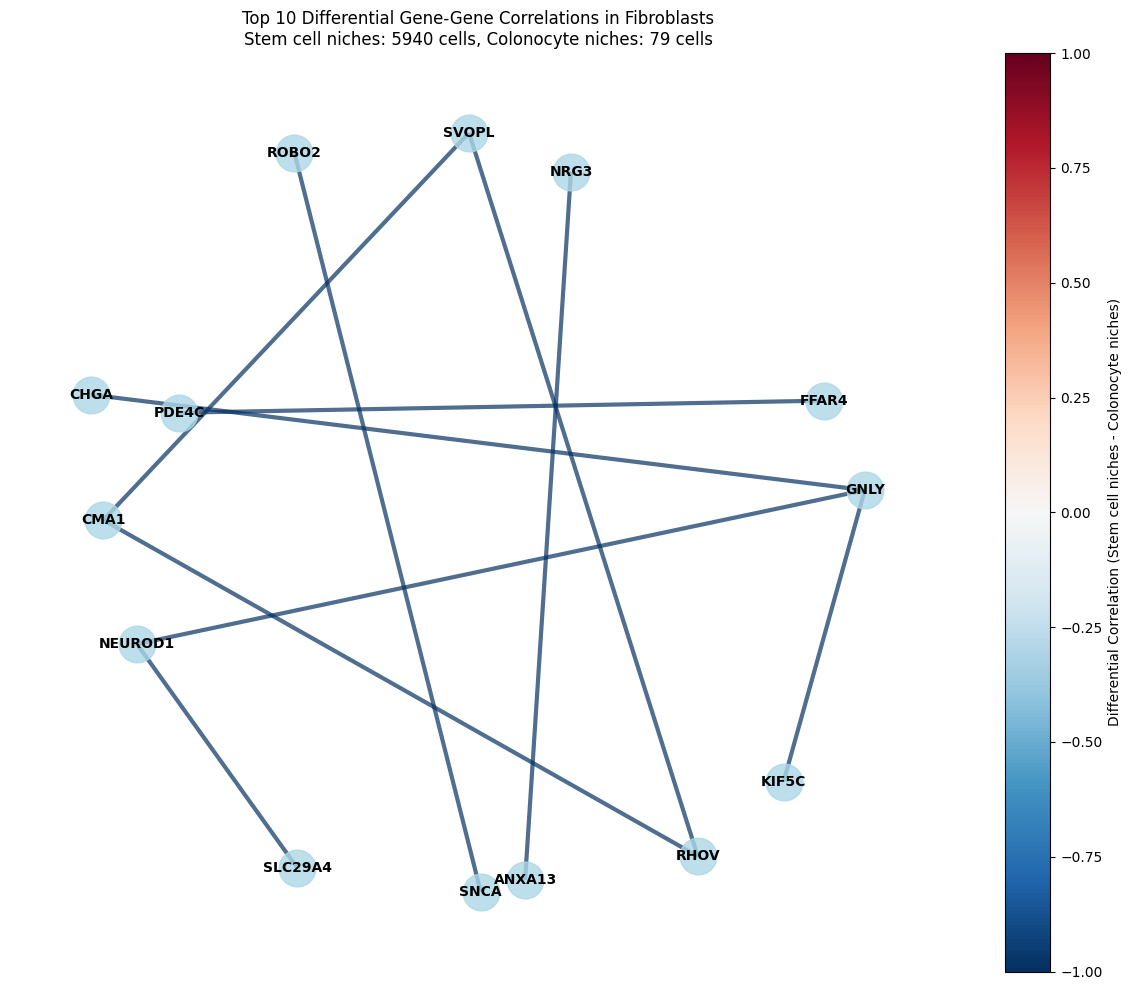

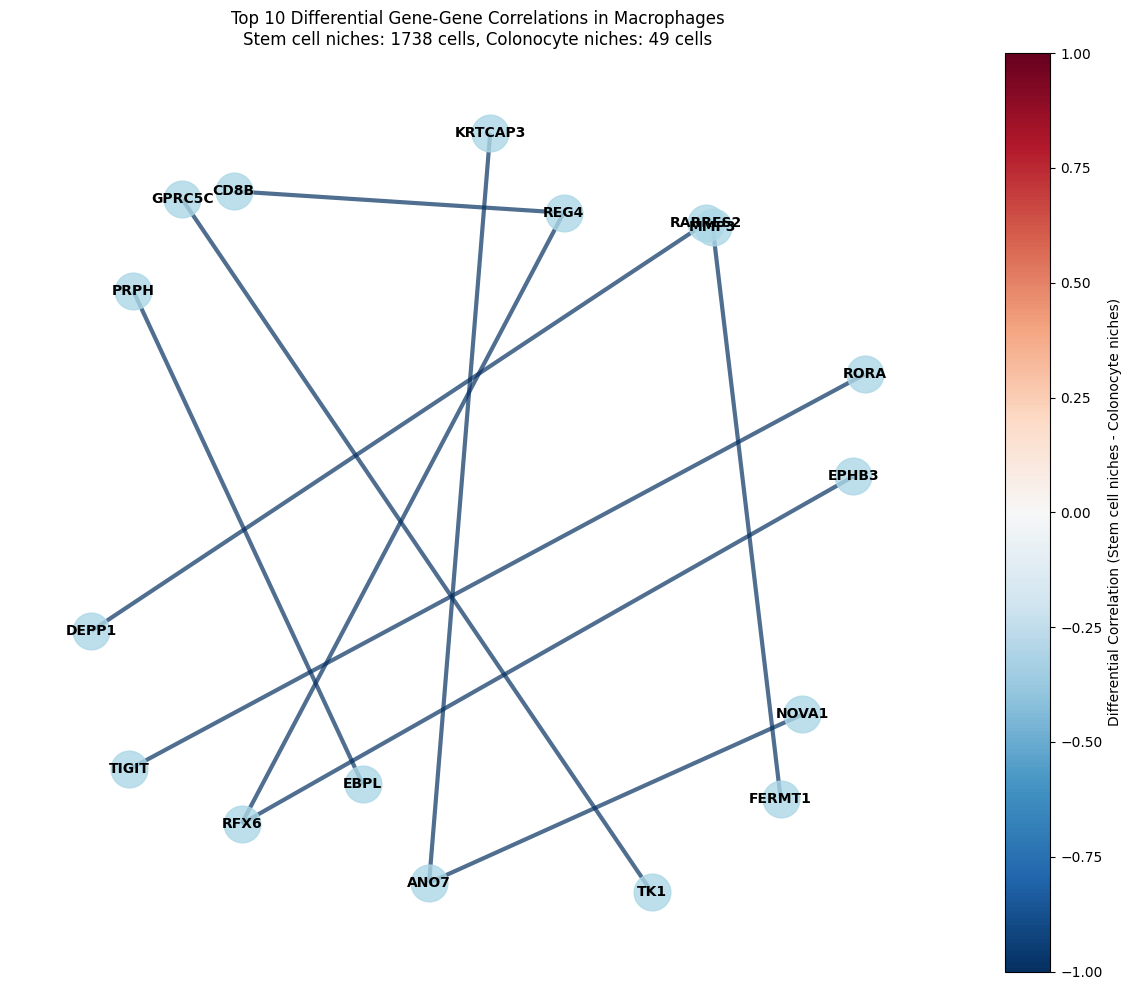

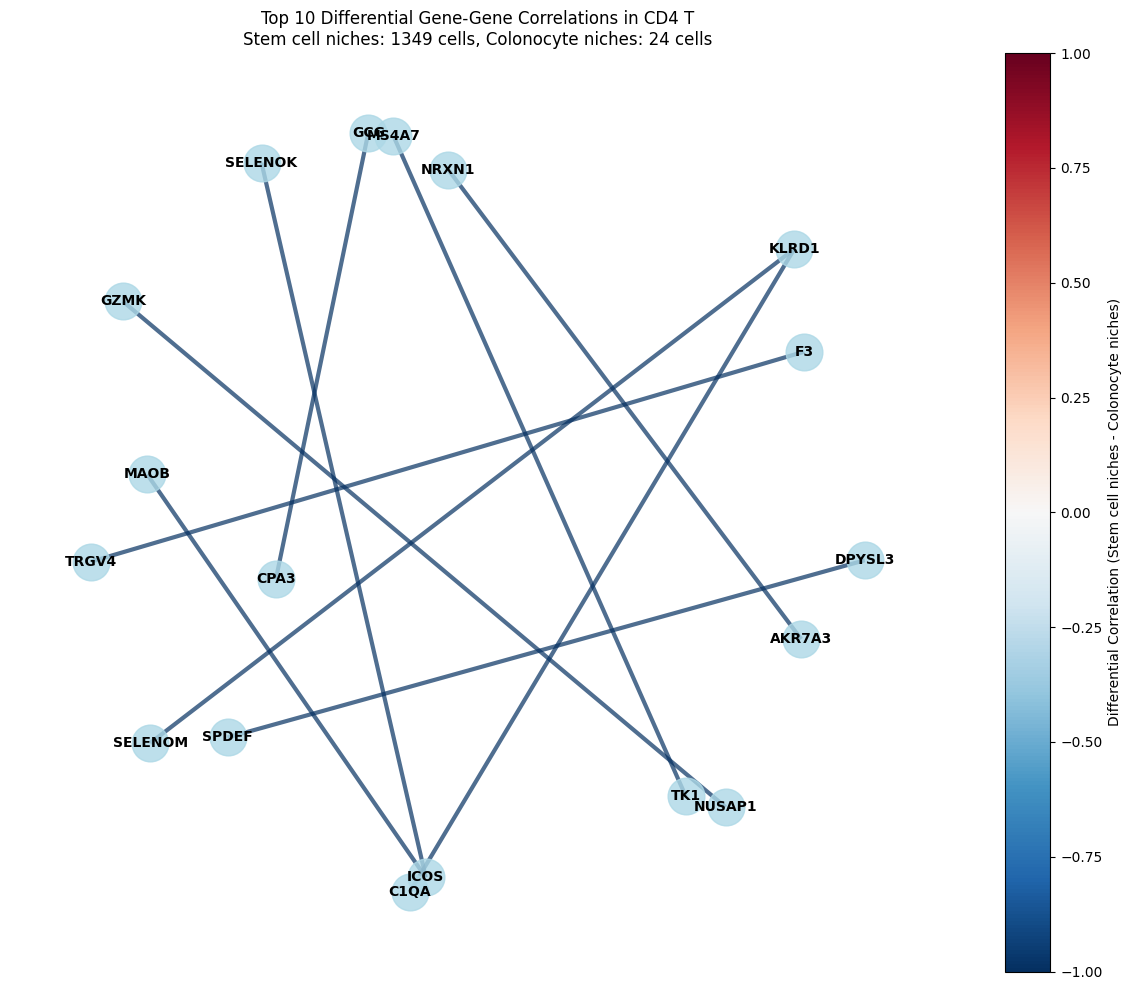

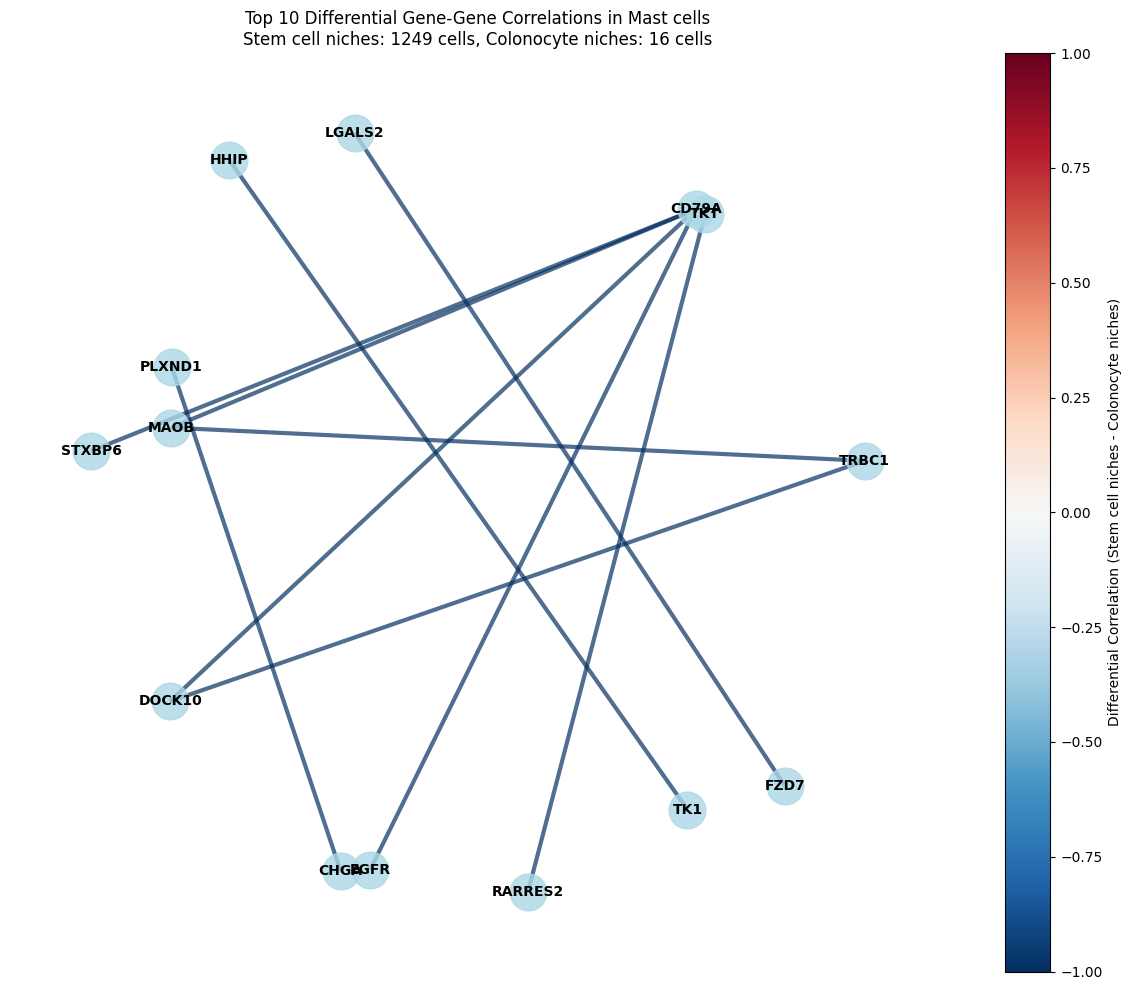

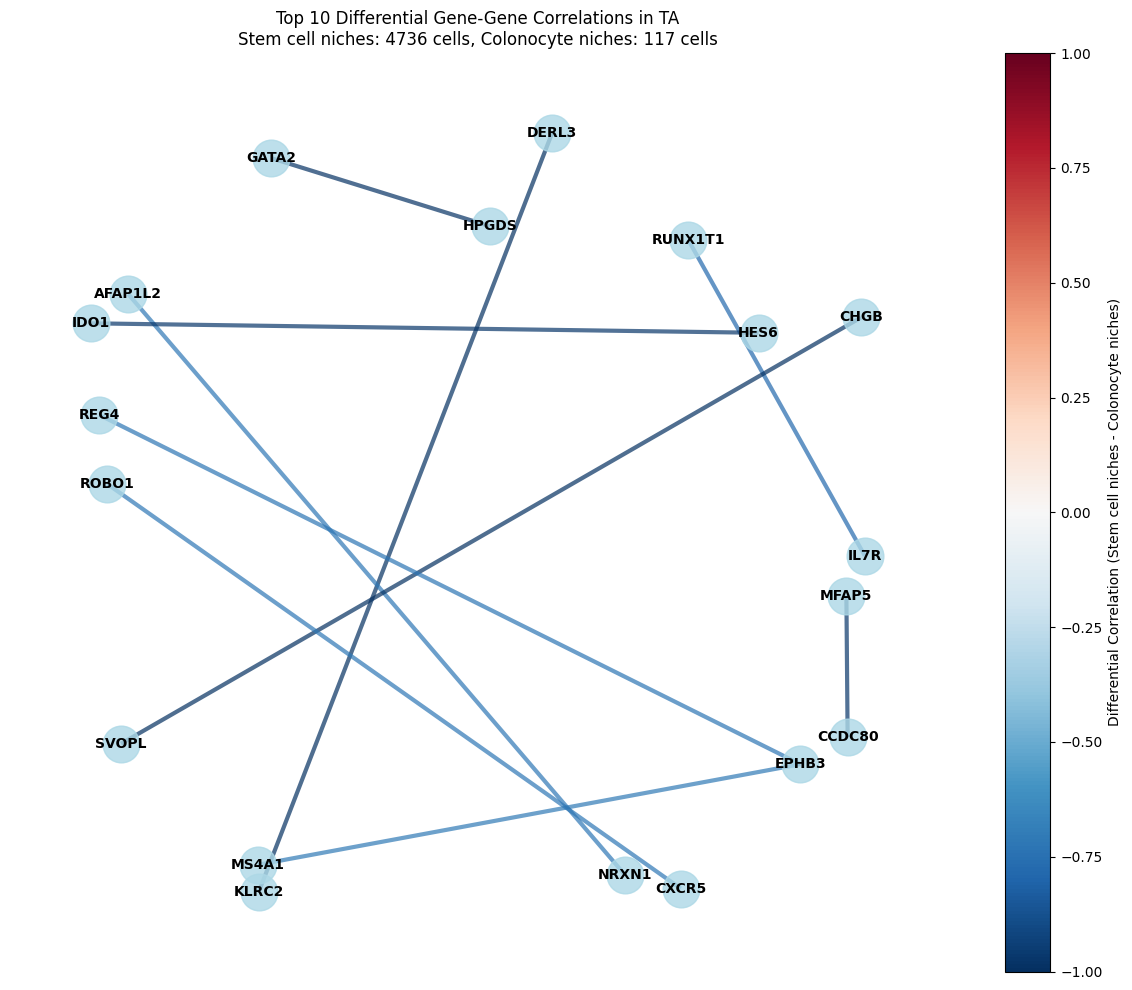

In [41]:
# Generate network visualizations for all cell types
for cell_type in results.keys():
    visualize_differential_network(cell_type, results)

## Summarize the Most Consistent Network Changes Across Cell Types

In [42]:
def summarize_network_changes(results):
    """Summarize the most consistent network changes across cell types."""
    # Collect all significant changes
    all_changes = []
    
    for cell_type, result in results.items():
        sig_changes = result['significant_changes']
        
        if len(sig_changes) > 0:
            # Add cell type information
            sig_changes = sig_changes.copy()
            sig_changes['cell_type'] = cell_type
            
            all_changes.append(sig_changes)
    
    if not all_changes:
        print("No significant changes found in any cell type")
        return None
    
    # Combine all changes
    all_changes_df = pd.concat(all_changes, ignore_index=True)
    
    # Create a unique identifier for each gene pair
    all_changes_df['gene_pair'] = all_changes_df.apply(
        lambda x: tuple(sorted([x['gene1'], x['gene2']])), axis=1)
    
    # Count occurrences of each gene pair
    pair_counts = all_changes_df.groupby('gene_pair').size().reset_index(name='frequency')
    
    # Calculate average magnitude of change for each gene pair
    pair_magnitude = all_changes_df.groupby('gene_pair')['abs_diff'].mean().reset_index(name='avg_magnitude')
    
    # Merge counts and magnitudes
    pair_summary = pd.merge(pair_counts, pair_magnitude, on='gene_pair')
    
    # Sort by frequency and then magnitude
    pair_summary = pair_summary.sort_values(['frequency', 'avg_magnitude'], ascending=False)
    
    # Extract gene1 and gene2 from gene_pair
    pair_summary['gene1'] = pair_summary['gene_pair'].apply(lambda x: x[0])
    pair_summary['gene2'] = pair_summary['gene_pair'].apply(lambda x: x[1])
    
    # Drop gene_pair column
    pair_summary = pair_summary.drop('gene_pair', axis=1)
    
    # Reorder columns
    pair_summary = pair_summary[['gene1', 'gene2', 'frequency', 'avg_magnitude']]
    
    return pair_summary

In [43]:
network_summary = summarize_network_changes(results)

Summary of most consistent network changes across cell types:
       gene1     gene2  frequency  avg_magnitude
1329    CHGA   NEUROD1          2       0.941901
1998   EPHB3      REG4          2       0.859876
313     AQP8   SELENOK          2       0.782234
1806    CYBB    TMIGD1          2       0.760798
2407    GZMA     KLRD1          2       0.757529
2579   HRCT1      REG4          2       0.736703
581     C1QC   SELENOK          2       0.731089
2837   KLRD1      PRF1          2       0.704438
1901  DOCK10      MAOB          2       0.696711
731      CA7    GUCA2B          2       0.695517
1977    EGFR      MAOB          2       0.686556
2843   KLRD1  TNFRSF25          2       0.676579
276     AQP8    CDKN2B          2       0.669927
2063      F3    SCNN1A          2       0.669369
2252   GNA11      GZMK          2       0.668671


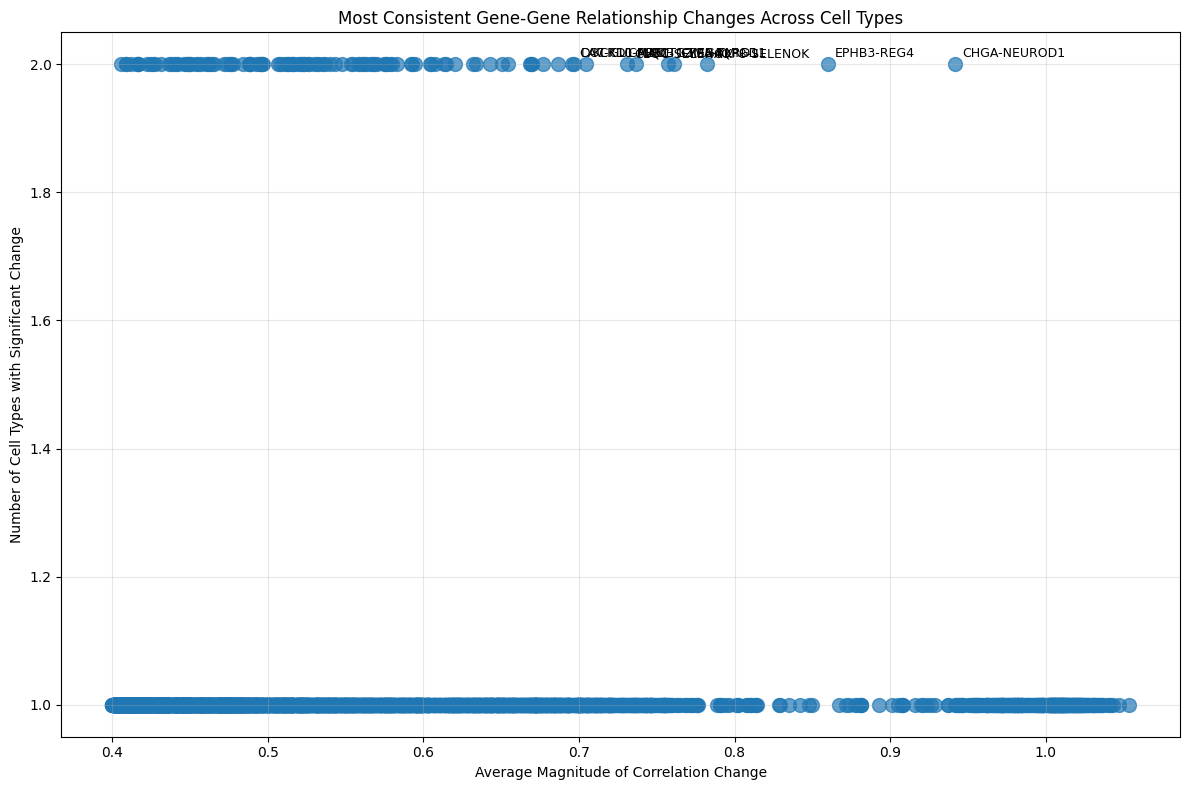

In [ ]:
if network_summary is not None:
    print("Summary of most consistent network changes across cell types:")
    print(network_summary.head(15))
    
    # Visualize top gene pairs
    plt.figure(figsize=(12, 8))
    
    # Plot frequency vs magnitude
    plt.scatter(network_summary['avg_magnitude'], network_summary['frequency'], 
               alpha=0.7, s=100)
    
    # Label top pairs
    for _, row in network_summary.head(10).iterrows():
        plt.annotate(f"{row['gene1']}-{row['gene2']}", 
                    (row['avg_magnitude'], row['frequency']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9)
    
    plt.xlabel('Average Magnitude of Correlation Change')
    plt.ylabel('Number of Cell Types with Significant Change')
    plt.title('Most Consistent Gene-Gene Relationship Changes Across Cell Types')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/NicheCompass/artifacts/single_sample/26032025_173236/figures/add_on_26/consistent_network_changes.png', dpi=300, bbox_inches='tight')
    plt.show()